In [1]:
from polygon import RESTClient
import pandas as pd
import numpy as np
import sklearn
import scipy
import matplotlib.pyplot as plt
import collections

import datetime

from tqdm import tqdm

import time


client = RESTClient(api_key = '938pvdrIpW2TtCgbcGG514_foywAEx6y')

In [12]:
price_performance = collections.defaultdict(list)
ticker = "VIXY"

enormous_frame = pd.DataFrame({})

# List Aggregates (Bars)
print('got here')

for agg in tqdm(client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000)):
    if datetime.datetime.fromtimestamp(agg.timestamp/1000).time()>=datetime.time(9, 30) and datetime.datetime.fromtimestamp(agg.timestamp/1000).time()<=datetime.time(16,0):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)

ticker_hist = pd.DataFrame(price_performance)
ticker_hist['ticker'] = ticker

ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)


ticker_hist['logClose'] = np.log(ticker_hist['Close'])
ticker_hist['logOpen'] = np.log(ticker_hist['Open'])

ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

enormous_frame = pd.concat([enormous_frame, ticker_hist])
tickers = pd.read_html(
    'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')[0]
print(tickers.head())

for ticker in tqdm(tickers['Symbol']):
    price_performance = collections.defaultdict(list)
    aggs = []
    for agg in client.list_aggs(ticker=ticker, multiplier=1, timespan="minute", from_="2022-09-21", to="2024-09-20", limit=50000):
        price_performance['Open'].append(agg.open)
        price_performance['Close'].append(agg.close)
        price_performance['high'].append(agg.high)
        price_performance['low'].append(agg.low)
        price_performance['volume'].append(agg.volume)
        price_performance['Datetime'].append(datetime.datetime.fromtimestamp(agg.timestamp/1000))
        price_performance['transactions'].append(agg.transactions)
    
    ticker_hist = pd.DataFrame(price_performance)
    if len(ticker_hist)>0:
        ticker_hist['ticker'] = ticker
        
        ticker_hist['Date'] = ticker_hist.apply(lambda row: row['Datetime'].date(), axis=1)
        ticker_hist['Time'] = ticker_hist.apply(lambda row: row['Datetime'].time(), axis=1)
        
        
        ticker_hist['logClose'] = np.log(ticker_hist['Close'])
        ticker_hist['logOpen'] = np.log(ticker_hist['Open'])
        
        ticker_hist['logReturns'] = ticker_hist['logClose'] - ticker_hist['logOpen']

        enormous_frame = pd.concat([enormous_frame, ticker_hist])


got here


230513it [00:04, 52429.64it/s]


  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


100%|███████████████████████████████████████| 503/503 [3:42:09<00:00, 26.50s/it]


In [17]:
enormous_frame.to_parquet('returns_data_2022_09_21_2024_09_20_minute.parquet', engine = 'pyarrow')

In [22]:
enormous_frame_time_filtered = enormous_frame[(enormous_frame['Time']<=datetime.time(16,0,0)) & (enormous_frame['Time']>=datetime.time(9,30,0))]

In [27]:
mean_volumes_by_time = enormous_frame_time_filtered.groupby('Time')['volume'].mean()

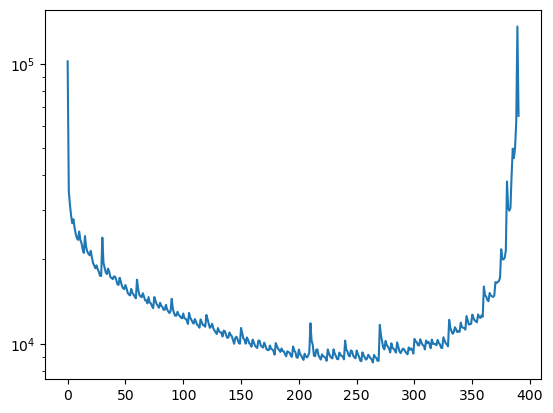

In [32]:
plt.plot(mean_volumes_by_time.values)
plt.yscale('log')

In [86]:
mean_logReturns_by_time = enormous_frame_time_filtered.groupby('Time')['logReturns'].mean()

In [2]:
plt.plot(mean_logReturns_by_time.values)
plt.plot(abs(mean_logReturns_by_time.values))


NameError: name 'plt' is not defined

In [112]:
import polars as pl

enormous_frame_time_filtered = pl.from_pandas(enormous_frame_time_filtered)

In [113]:
enormous_frame_time_filtered

Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logClose,logOpen,logReturns
f64,f64,f64,f64,f64,datetime[ns],i64,str,date,time,f64,f64,f64
73.15,72.975,73.15,72.85,33146.8,2022-09-21 09:30:00,515,"""VIXY""",2022-09-21,09:30:00,4.290117,4.292512,-0.002395
72.9935,72.89,72.9935,72.875,3189.2,2022-09-21 09:31:00,54,"""VIXY""",2022-09-21,09:31:00,4.288951,4.29037,-0.001419
72.95,72.95,73.0,72.9,3230.0,2022-09-21 09:32:00,89,"""VIXY""",2022-09-21,09:32:00,4.289774,4.289774,0.0
73.0,73.2,73.2,73.0,3078.6,2022-09-21 09:33:00,64,"""VIXY""",2022-09-21,09:33:00,4.293195,4.290459,0.002736
73.1525,73.175,73.2,73.1,2965.6,2022-09-21 09:34:00,59,"""VIXY""",2022-09-21,09:34:00,4.292854,4.292546,0.000308
…,…,…,…,…,…,…,…,…,…,…,…,…
192.58,192.55,192.63,192.505,14207.0,2024-09-20 15:56:00,262,"""ZTS""",2024-09-20,15:56:00,5.260356,5.260512,-0.000156
192.565,192.775,192.775,192.54,14662.0,2024-09-20 15:57:00,318,"""ZTS""",2024-09-20,15:57:00,5.261524,5.260434,0.00109
192.77,192.66,192.77,192.44,31114.0,2024-09-20 15:58:00,563,"""ZTS""",2024-09-20,15:58:00,5.260927,5.261498,-0.000571


In [116]:
a_params = {}
b_params = {}

for ticker in tqdm(all_tickers):
    a_params[ticker] = {}
    b_params[ticker] = {}
    
    # Filter the Polars DataFrame for the specific ticker
    ticker_hist = enormous_frame_time_filtered.filter(pl.col('ticker') == ticker)
    
    if ticker_hist.height > 0:  # Equivalent to len() in Pandas
        for date in dates:
            # Filter the DataFrame for the specific date
            ticker_hist_date = ticker_hist.filter(pl.col('Date') == date)
            ticker_hist_date = ticker_hist_date.to_pandas()
            
            if len(ticker_hist_date)>0:
                ticker_hist_date = ticker_hist_date.sort_values('logReturns').reset_index(drop = True)
                ticker_hist_date.loc[:, 'cumulative_volume'] = ticker_hist_date['volume'].cumsum()/ticker_hist_date['volume'].sum()
        
                a_param = ticker_hist_date[ticker_hist_date['cumulative_volume']>=0.5]['logReturns'].iloc[0]
                mae = np.sum(abs(a_param - ticker_hist_date['logReturns'])*ticker_hist_date['cumulative_volume'])
                bessel_corrected_mae = mae * len(ticker_hist_date)/(len(ticker_hist_date)-1)
                a_params[ticker][date] = a_param
                b_params[ticker][date] = bessel_corrected_mae

100%|█████████████████████████████████████████| 504/504 [13:24<00:00,  1.60s/it]


In [117]:
a_params_df = pd.DataFrame(a_params)
b_params_df = pd.DataFrame(b_params)

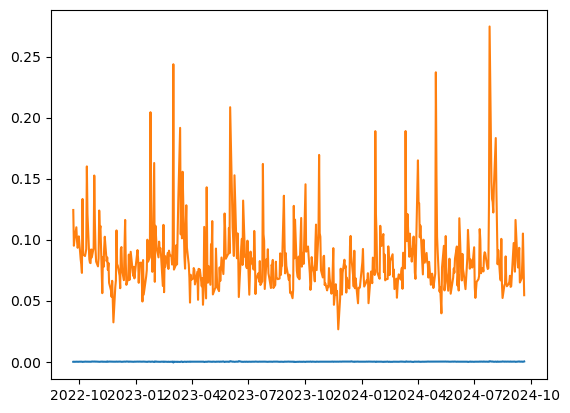

In [122]:
plt.plot(a_params_df['MMM'])
plt.plot(b_params_df['MMM'])

In [134]:
pacfs

array([ 1., nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan])

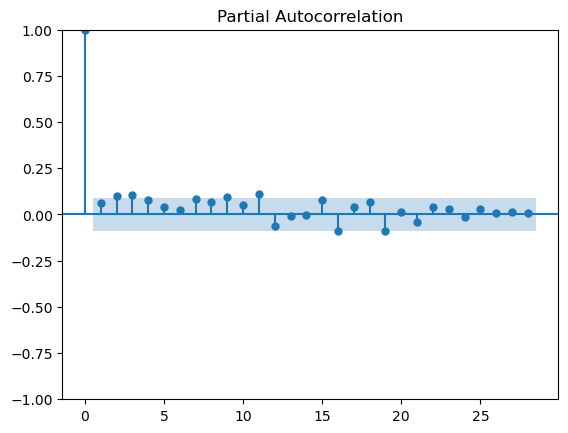

In [142]:
import statsmodels
import statsmodels.tsa.stattools
import statsmodels.graphics.tsaplots

pacfs, confints = statsmodels.tsa.stattools.pacf(a_params_df.iloc[:,0], nlags = 40, alpha=0.05)
statsmodels.graphics.tsaplots.plot_pacf(a_params_df.iloc[:,0])
plt.show()

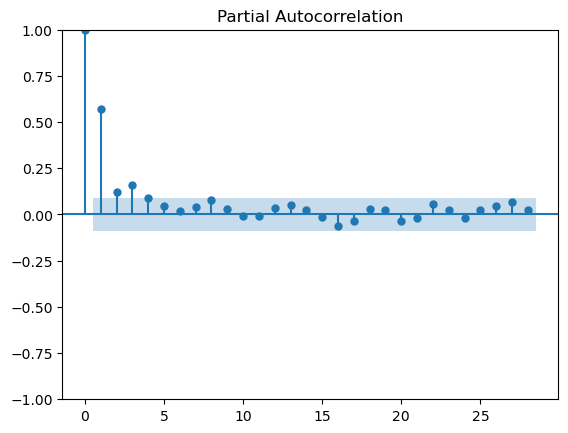

In [145]:
pacfs, confints = statsmodels.tsa.stattools.pacf(b_params_df.iloc[:,1], nlags = 40, alpha=0.05)
statsmodels.graphics.tsaplots.plot_pacf(b_params_df.iloc[:,1])
plt.show()

In [152]:
a_b_params_concat = pd.concat([a_params_df, b_params_df], axis = 1)

In [155]:
a_b_params

,MMM,MMM
MMM,1.000000,-0.234680
AOS,0.157821,0.037062
ABT,0.096567,-0.131002
ABBV,0.182550,-0.057592
ACN,0.102098,-0.033965
...,...,...
YUM,-0.049187,0.375284
ZBRA,-0.006900,0.238544
ZBH,-0.050082,0.211477
ZTS,-0.055360,0.312660


In [111]:
import polars as pl

enormous_frame_time_filtered = pl.from_pandas(enormous_frame_time_filtered)

a_params = {}
b_params = {}
for ticker in tqdm(all_tickers):
    a_params[ticker] = {}
    b_params[ticker] = {}
    ticker_hist = enormous_frame_time_filtered[enormous_frame_time_filtered['ticker'] == ticker]
    if len(ticker_hist)>0:
        for date in dates:
            ticker_hist_date = ticker_hist[ticker_hist['Date'] == date]

        

  0%|                                                   | 0/504 [00:06<?, ?it/s]


TypeError: Invalid comparison between dtype=datetime64[ns] and int

In [110]:
ticker_hist

,Open,Close,high,low,volume,Datetime,transactions,ticker,Date,Time,logClose,logOpen,logReturns
